# Week 2 — Linear Regression with Regularization

**Integrated Capstone Project: Breast Cancer (two datasets)**

### Notebook purpose
This notebook applies the Week 2 concepts — **regularized linear regression with ridge (L2), lasso (L1), and elastic net (L1 + L2) penalties** — to the two breast cancer datasets I use throughout my capstone:

1. **Breast Cancer Wisconsin (Diagnostic)** — tumor morphology measurements from images (radius, texture, perimeter, area, smoothness, concavity).
2. **Breast Cancer Coimbra** — clinical, anthropometric, and blood-based biomarkers (age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, MCP-1).

I run the same regularization methods on each dataset so I can compare how shrinkage and feature selection behave on two very different kinds of healthcare data. I do not merge the datasets, because they contain different patients and different variables; I analyze each separately and compare at the end.

### Project question
> To what extent can measurable patient and tumor characteristics help distinguish breast cancer cases from non-cancer cases?

### Modeling choice
Both outcomes are categorical, so I use linear regression as an exploratory **linear probability model** (predicted scores clipped to 0–1). This is not the final clinical model — later weeks use logistic regression, SVMs, decision trees, and random forests. For Week 2, this lets me focus on regularization, coefficient shrinkage, and overfitting.

The models compared in each part are:
1. Ordinary linear regression (baseline)
2. Ridge regression
3. Lasso regression
4. Elastic net regression

### Roadmap
- **Part 1** — Breast Cancer Wisconsin analysis
- **Part 2** — Breast Cancer Coimbra analysis
- **Part 3** — Comparison and overall Week 2 conclusions
- **References**


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Dataset
from sklearn.datasets import load_breast_cancer
# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## Part 1 — Breast Cancer Wisconsin (Diagnostic)

This dataset is loaded from `sklearn.datasets.load_breast_cancer`. It contains tumor measurements computed from digitized images, with each tumor labeled benign or malignant. The libraries imported above cover loading, splitting, scaling, the regularized models, hyperparameter tuning, and evaluation.

### 1.1 Load and prepare the data

Load and prepare the dataset

The sklearn version of the Breast Cancer Wisconsin Diagnostic dataset uses:

- `0 = malignant`
- `1 = benign`

For my notebook, I switch this around and create a new target column:

- `diagnosis_malignant = 1` means malignant
- `diagnosis_malignant = 0` means benign

This makes the interpretation easier because higher predicted values mean a higher predicted chance of malignancy.

In [2]:
# Load dataset
cancer = load_breast_cancer()
# Create dataframe
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
# Clean column names so they are easier to type
df.columns = df.columns.str.replace(" ", "_")
# Create target variable: 1 = malignant, 0 = benign
df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
df["diagnosis_label"] = np.where(df["diagnosis_malignant"] == 1, "Malignant", "Benign")
print("Dataset shape:", df.shape)
print("\nDiagnosis counts:")
print(df["diagnosis_label"].value_counts())
df.head()


Dataset shape: (569, 32)

Diagnosis counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


### 1.2 Exploratory analysis

Before I fit the models, I want to look at how the variables relate to diagnosis. From my previous EDA, I already noticed that tumor size-related variables such as radius, perimeter, and area are important. I also noticed that many of these variables are highly correlated, which is one reason regularized regression is useful here.

Regularization is helpful because it can control large coefficients and make the model less sensitive to overlapping predictors.

In [3]:
# Separate features and target
target_col = "diagnosis_malignant"
label_col = "diagnosis_label"
feature_cols = [col for col in df.columns if col not in [target_col, label_col]]
X = df[feature_cols]
y = df[target_col]
print("Number of features:", X.shape[1])
print("Number of rows:", X.shape[0])


Number of features: 30
Number of rows: 569


In [4]:
# Mean feature values by diagnosis
# This helps me see whether malignant tumors tend to have higher/lower values for certain features.
group_means = df.groupby("diagnosis_label")[feature_cols].mean().T
group_means.head(10)


diagnosis_label,Benign,Malignant
mean_radius,12.146524,17.462830
mean_texture,17.914762,21.604906
mean_perimeter,78.075406,115.365377
mean_area,462.790196,978.376415
mean_smoothness,0.092478,0.102898
mean_compactness,0.080085,0.145188
mean_concavity,0.046058,0.160775
mean_concave_points,0.025717,0.087990
mean_symmetry,0.174186,0.192909
mean_fractal_dimension,0.062867,0.062680


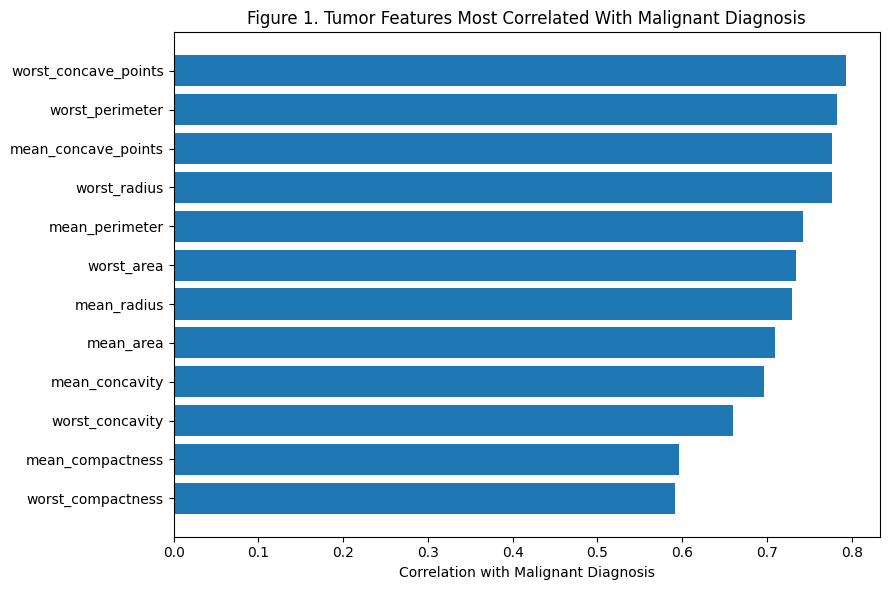

,feature,correlation_with_malignant
0,worst_compactness,0.590998
1,mean_compactness,0.596534
2,worst_concavity,0.659610
3,mean_concavity,0.696360
4,mean_area,0.708984
5,mean_radius,0.730029
6,worst_area,0.733825
7,mean_perimeter,0.742636
8,worst_radius,0.776454
9,mean_concave_points,0.776614


In [5]:
# Figure 1: Top features most correlated with malignant diagnosis
corr_with_target = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
top_corr = corr_with_target.abs().sort_values(ascending=False).head(12)
top_corr_signed = corr_with_target.loc[top_corr.index].sort_values()
plt.figure(figsize=(9, 6))
plt.barh(top_corr_signed.index, top_corr_signed.values)
plt.xlabel("Correlation with Malignant Diagnosis")
plt.title("Figure 1. Tumor Features Most Correlated With Malignant Diagnosis")
plt.tight_layout()
plt.show()
pd.DataFrame({
    "feature": top_corr_signed.index,
    "correlation_with_malignant": top_corr_signed.values
})


#### EDA note

The correlation results give me an early idea of which tumor measurements may be useful. If the strongest features are mostly size-related variables, that supports my earlier finding that tumor size is a major signal in this dataset.

However, I also have to be careful. If many features are highly correlated with each other, a regular linear regression model may have unstable coefficients. This is where ridge, lasso, and elastic net regression become useful.

### 1.3 Train-test split

I split the data into training and testing sets. I also use stratification so that the benign and malignant proportions stay similar in both sets.

This is one way I am trying to avoid overfitting. I want to see whether the model works on new data, not just the data it learned from.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Training shape: (455, 30)
Testing shape: (114, 30)

Training target distribution:
diagnosis_malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing target distribution:
diagnosis_malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### 1.4 Why scaling matters for regularization

Ridge, lasso, and elastic net all use regularization. Regularization penalizes coefficient size.

Because the features are measured on different scales, I need to standardize them first. For example, area has much larger numeric values than smoothness. Without scaling, the penalty would not treat all predictors fairly.

I use a pipeline so that scaling is fit only on the training data during cross-validation. This helps prevent data leakage.

### 1.5 Evaluation function

The main regression metrics I am using are:

- **RMSE:** Average prediction error, with larger errors penalized more
- **MAE:** Average absolute error
- **R²:** How much variation the model explains

Since my outcome is 0/1 diagnosis, I also include classification-style checks using a 0.50 threshold:

- Accuracy
- Recall for malignant cases
- Precision for malignant cases

For this healthcare problem, recall is important because missing a malignant case would be a serious mistake. I am still treating this as a Week 2 regression exercise, but I want the interpretation to connect back to the real problem.

In [7]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Fit model and return regression and classification-style metrics."""
    model.fit(X_train, y_train)
    # Linear regression can predict values below 0 or above 1, so I clip them for easier interpretation.
    train_pred = np.clip(model.predict(X_train), 0, 1)
    test_pred = np.clip(model.predict(X_test), 0, 1)
    # Convert predicted score to class using 0.50 threshold
    test_class = (test_pred >= 0.50).astype(int)
    results = {
        "model": name,
        "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "train_MAE": mean_absolute_error(y_train, train_pred),
        "test_MAE": mean_absolute_error(y_test, test_pred),
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
        "accuracy_at_0.5": accuracy_score(y_test, test_class),
        "recall_malignant_at_0.5": recall_score(y_test, test_class, pos_label=1),
        "precision_malignant_at_0.5": precision_score(y_test, test_class, pos_label=1)
    }
    return results, train_pred, test_pred


### 1.6 Baseline: ordinary linear regression

I start with ordinary linear regression so I have a baseline. This model does not use regularization. It gives me something to compare ridge, lasso, and elastic net against.

In [8]:
baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
baseline_results, baseline_train_pred, baseline_test_pred = evaluate_model(
    "Ordinary Linear Regression",
    baseline_model,
    X_train,
    X_test,
    y_train,
    y_test
)
pd.DataFrame([baseline_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Ordinary Linear Regression,0.210002,0.230524,0.140449,0.156241,0.811559,0.771619,0.964912,0.904762,1.0


#### Baseline interpretation

This baseline tells me how well a normal linear regression model performs before adding regularization. If ridge, lasso, or elastic net improves the test error or creates a simpler model, then regularization is adding value.

### 1.7 Ridge regression

Ridge regression uses an L2 penalty. My understanding is that ridge does not usually remove features completely. Instead, it shrinks coefficients so that no single variable becomes too dominant.

This is useful for my dataset because many tumor measurements are correlated with each other. Ridge can keep the correlated predictors in the model while making the coefficients more stable.

The main hyperparameter is:

- `alpha`: controls the strength of regularization  
  - small alpha = closer to ordinary linear regression  
  - large alpha = stronger shrinkage

In [9]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ridge_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
ridge_param_grid = {
    "model__alpha": np.logspace(-4, 2, 25)
}
ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv
)
ridge_grid.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_grid.best_params_["model__alpha"])
print("Best Ridge CV RMSE:", np.sqrt(-ridge_grid.best_score_))
ridge_results, ridge_train_pred, ridge_test_pred = evaluate_model(
    "Ridge Regression",
    ridge_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test
)
pd.DataFrame([ridge_results])


Best Ridge alpha: 3.1622776601683795
Best Ridge CV RMSE: 0.24673056711740227


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Ridge Regression,0.212596,0.232274,0.143897,0.161331,0.806875,0.768137,0.964912,0.904762,1.0


### 1.8 Lasso regression

Lasso regression uses an L1 penalty. Lasso can shrink some coefficients all the way to zero. This means lasso can also act like feature selection.

This is helpful for my dataset because there are 30 tumor features, and some of them are measuring similar things. If lasso keeps only some features, it may make the model easier to explain.

The main hyperparameter is:

- `alpha`: controls the strength of regularization  
  - small alpha = less shrinkage  
  - large alpha = more shrinkage and possibly more coefficients set to zero

In [10]:
lasso_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000, random_state=42))
])
lasso_param_grid = {
    "model__alpha": np.logspace(-4, 1, 25)
}
lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv
)
lasso_grid.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_grid.best_params_["model__alpha"])
print("Best Lasso CV RMSE:", np.sqrt(-lasso_grid.best_score_))
lasso_results, lasso_train_pred, lasso_test_pred = evaluate_model(
    "Lasso Regression",
    lasso_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test
)
pd.DataFrame([lasso_results])


Best Lasso alpha: 0.0011006941712522103
Best Lasso CV RMSE: 0.2453009463304729


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Lasso Regression,0.212875,0.230534,0.143988,0.159762,0.806367,0.7716,0.964912,0.904762,1.0


### 1.9 Elastic net regression

Elastic net combines ridge and lasso. It uses both L1 and L2 penalties.

This is useful when there are correlated features. Lasso may choose only one variable from a group of correlated variables, while ridge keeps all of them but shrinks them. Elastic net gives a balance between both approaches.

The main hyperparameters are:

- `alpha`: total strength of regularization
- `l1_ratio`: balance between lasso and ridge  
  - `l1_ratio = 1` is mostly lasso  
  - `l1_ratio = 0` is mostly ridge  
  - values between 0 and 1 mix both penalties

In [11]:
elastic_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=42))
])
elastic_param_grid = {
    "model__alpha": np.logspace(-4, 1, 20),
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid = GridSearchCV(
    estimator=elastic_pipe,
    param_grid=elastic_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv
)
elastic_grid.fit(X_train, y_train)
print("Best Elastic Net alpha:", elastic_grid.best_params_["model__alpha"])
print("Best Elastic Net l1_ratio:", elastic_grid.best_params_["model__l1_ratio"])
print("Best Elastic Net CV RMSE:", np.sqrt(-elastic_grid.best_score_))
elastic_results, elastic_train_pred, elastic_test_pred = evaluate_model(
    "Elastic Net Regression",
    elastic_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test
)
pd.DataFrame([elastic_results])


Best Elastic Net alpha: 0.0011288378916846883
Best Elastic Net l1_ratio: 0.9
Best Elastic Net CV RMSE: 0.2453976111388175


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Elastic Net Regression,0.212717,0.23039,0.143814,0.159465,0.806654,0.771884,0.964912,0.904762,1.0


### 1.10 Model comparison

Now I compare all four models together. I am mainly looking at test RMSE and cross-validation RMSE. I also look at recall for malignant cases because this is a healthcare-related dataset.

In [12]:
results_df = pd.DataFrame([
    baseline_results,
    ridge_results,
    lasso_results,
    elastic_results
])
results_df.sort_values("test_RMSE")


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
3,Elastic Net Regression,0.212717,0.230390,0.143814,0.159465,0.806654,0.771884,0.964912,0.904762,1.0
0,Ordinary Linear Regression,0.210002,0.230524,0.140449,0.156241,0.811559,0.771619,0.964912,0.904762,1.0
2,Lasso Regression,0.212875,0.230534,0.143988,0.159762,0.806367,0.771600,0.964912,0.904762,1.0
1,Ridge Regression,0.212596,0.232274,0.143897,0.161331,0.806875,0.768137,0.964912,0.904762,1.0


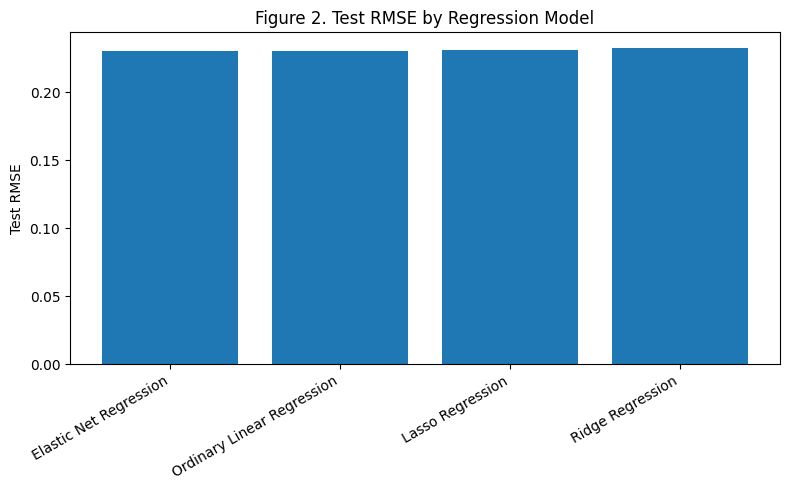

In [13]:
# Figure 2: Test RMSE comparison
plot_df = results_df.sort_values("test_RMSE")
plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["test_RMSE"])
plt.ylabel("Test RMSE")
plt.title("Figure 2. Test RMSE by Regression Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


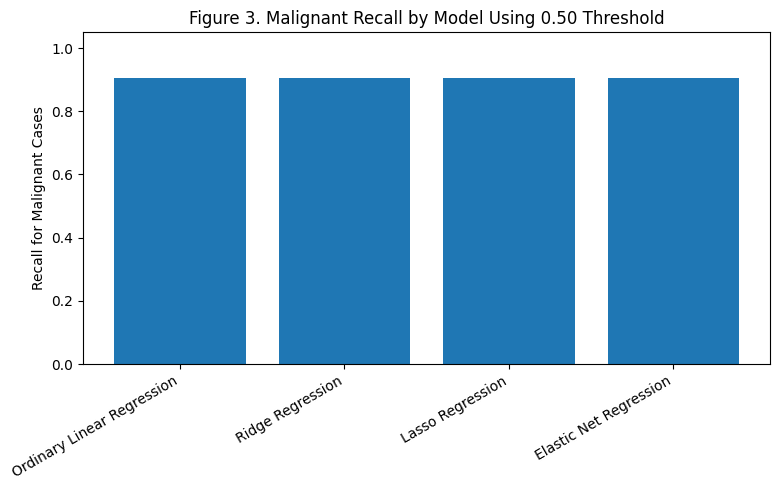

In [14]:
# Figure 3: Test recall for malignant diagnosis
plot_df = results_df.sort_values("recall_malignant_at_0.5", ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["recall_malignant_at_0.5"])
plt.ylabel("Recall for Malignant Cases")
plt.title("Figure 3. Malignant Recall by Model Using 0.50 Threshold")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


#### Model comparison interpretation

After running this cell, I would compare the models based on both error and interpretability. If ridge has similar or better test RMSE than ordinary linear regression, that suggests coefficient shrinkage helped. If lasso has similar performance while using fewer variables, that makes it easier to explain. Elastic net is useful if it gives a good balance between prediction and feature selection.

### 1.11 Cross-validation comparison

The train-test split gives one estimate of model performance, but it depends on one random split. Cross-validation gives a more stable view because the model is tested across multiple folds.

In [15]:
def cv_rmse(model, X, y, cv):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=cv
    )
    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean(), rmse_scores.std()
cv_summary = []
models_for_cv = {
    "Ordinary Linear Regression": baseline_model,
    "Ridge Regression": ridge_grid.best_estimator_,
    "Lasso Regression": lasso_grid.best_estimator_,
    "Elastic Net Regression": elastic_grid.best_estimator_
}
for name, model in models_for_cv.items():
    mean_rmse, std_rmse = cv_rmse(model, X, y, cv)
    cv_summary.append({
        "model": name,
        "CV_RMSE_mean": mean_rmse,
        "CV_RMSE_std": std_rmse
    })
cv_summary_df = pd.DataFrame(cv_summary).sort_values("CV_RMSE_mean")
cv_summary_df


,model,CV_RMSE_mean,CV_RMSE_std
3,Elastic Net Regression,0.242302,0.019641
2,Lasso Regression,0.242333,0.019630
1,Ridge Regression,0.244142,0.020089
0,Ordinary Linear Regression,0.244810,0.019993


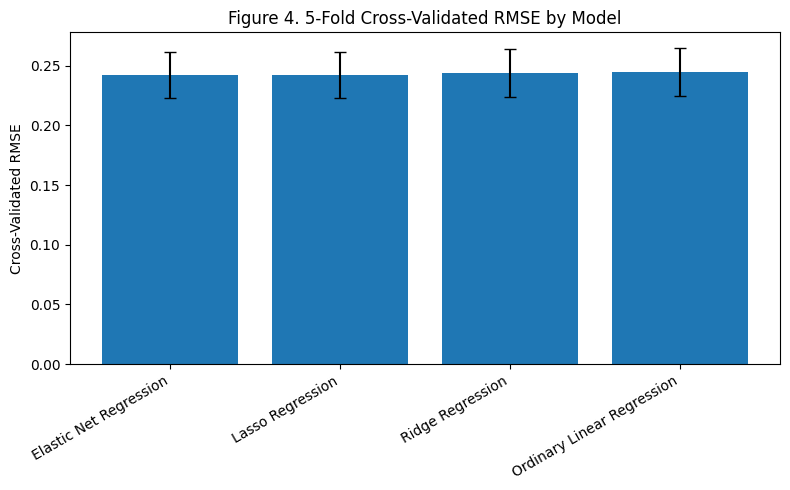

In [16]:
# Figure 4: Cross-validation RMSE comparison
plot_df = cv_summary_df.sort_values("CV_RMSE_mean")
plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["CV_RMSE_mean"], yerr=plot_df["CV_RMSE_std"], capsize=4)
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure 4. 5-Fold Cross-Validated RMSE by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 1.12 Coefficient comparison

One of the main reasons I want to use ridge, lasso, and elastic net is to understand what they do to coefficients.

- Ridge should shrink coefficients but usually keep most of them.
- Lasso can shrink some coefficients to exactly zero.
- Elastic net can do both, depending on the selected `alpha` and `l1_ratio`.

Because the features are standardized in the pipeline, the coefficients are more comparable than they would be on the original scale.

In [17]:
def get_coefficients(fitted_pipeline, feature_names, model_name):
    coefs = fitted_pipeline.named_steps["model"].coef_
    return pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
        "model": model_name
    })
coef_dfs = [
    get_coefficients(baseline_model.fit(X_train, y_train), feature_cols, "Ordinary Linear Regression"),
    get_coefficients(ridge_grid.best_estimator_, feature_cols, "Ridge Regression"),
    get_coefficients(lasso_grid.best_estimator_, feature_cols, "Lasso Regression"),
    get_coefficients(elastic_grid.best_estimator_, feature_cols, "Elastic Net Regression")
]
coef_df = pd.concat(coef_dfs, ignore_index=True)
# Show the largest coefficients for each model
coef_df.sort_values(["model", "abs_coefficient"], ascending=[True, False]).groupby("model").head(10)


,feature,coefficient,abs_coefficient,model
110,worst_radius,0.490267,0.490267,Elastic Net Regression
113,worst_area,-0.310010,0.310010,Elastic Net Regression
95,mean_compactness,-0.141377,0.141377,Elastic Net Regression
97,mean_concave_points,0.138513,0.138513,Elastic Net Regression
100,radius_error,0.134886,0.134886,Elastic Net Regression
116,worst_concavity,0.103768,0.103768,Elastic Net Regression
103,area_error,-0.085128,0.085128,Elastic Net Regression
106,concavity_error,-0.076102,0.076102,Elastic Net Regression
119,worst_fractal_dimension,0.069806,0.069806,Elastic Net Regression
107,concave_points_error,0.064789,0.064789,Elastic Net Regression


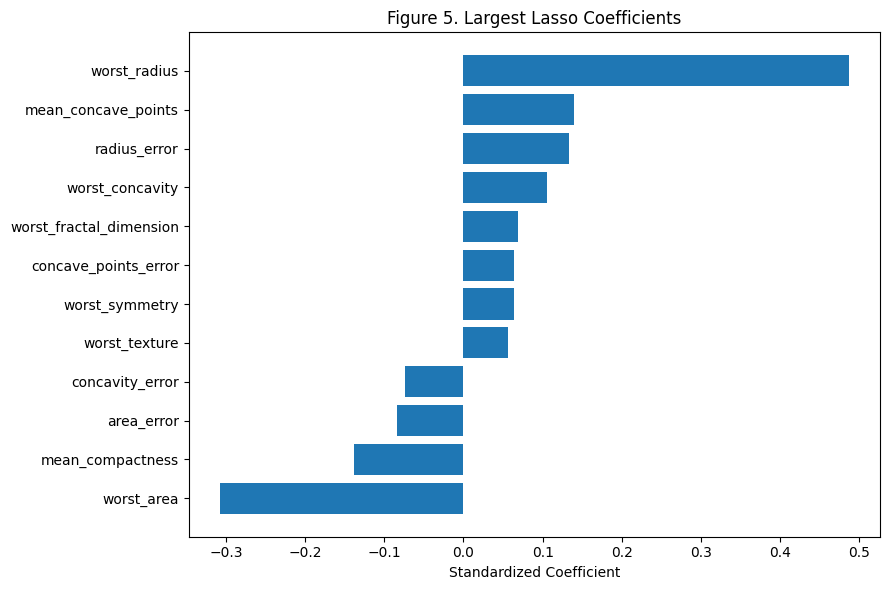

In [18]:
# Figure 5: Top coefficient magnitudes for lasso model
lasso_coef = coef_df[coef_df["model"] == "Lasso Regression"].copy()
lasso_top = lasso_coef.sort_values("abs_coefficient", ascending=False).head(12).sort_values("coefficient")
plt.figure(figsize=(9, 6))
plt.barh(lasso_top["feature"], lasso_top["coefficient"])
plt.xlabel("Standardized Coefficient")
plt.title("Figure 5. Largest Lasso Coefficients")
plt.tight_layout()
plt.show()


In [19]:
# Count how many coefficients were kept by each model
coef_count_df = (
    coef_df.assign(nonzero=lambda d: d["coefficient"].abs() > 1e-8)
    .groupby("model")["nonzero"]
    .sum()
    .reset_index()
    .rename(columns={"nonzero": "number_of_nonzero_coefficients"})
)
coef_count_df


,model,number_of_nonzero_coefficients
0,Elastic Net Regression,22
1,Lasso Regression,22
2,Ordinary Linear Regression,30
3,Ridge Regression,30


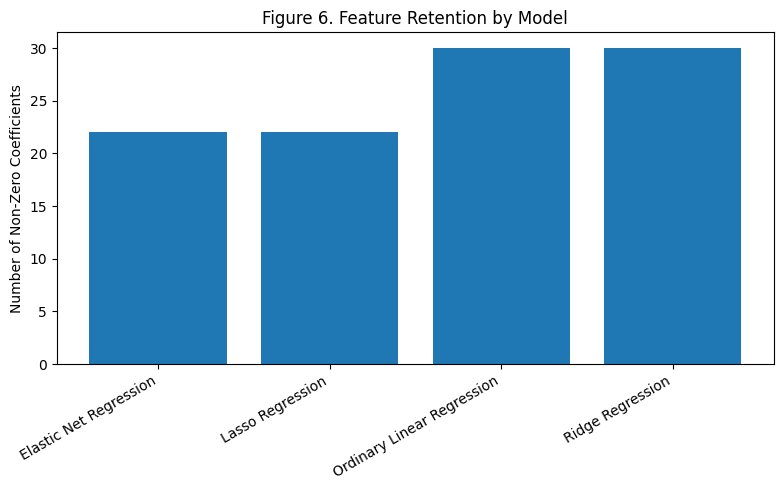

In [20]:
# Figure 6: Number of non-zero coefficients
plt.figure(figsize=(8, 5))
plt.bar(coef_count_df["model"], coef_count_df["number_of_nonzero_coefficients"])
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Figure 6. Feature Retention by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


#### Coefficient interpretation

This part helps me understand how the models behave differently. If lasso keeps fewer variables, it is easier to explain because it is doing feature selection. If ridge keeps most variables but shrinks them, it may be better when many related tumor features all contain useful information. Elastic net is in the middle because it can keep groups of related variables while still shrinking less useful coefficients.

### 1.13 Hyperparameter summary

This table shows the tuned hyperparameters. I am including this because the Milestone One rubric asks for metrics and hyperparameter tuning, not just final model output.

In [21]:
hyperparameter_summary = pd.DataFrame([
    {
        "model": "Ridge Regression",
        "best_alpha": ridge_grid.best_params_["model__alpha"],
        "best_l1_ratio": "Not applicable",
        "meaning": "Alpha controls how strongly ridge shrinks coefficients."
    },
    {
        "model": "Lasso Regression",
        "best_alpha": lasso_grid.best_params_["model__alpha"],
        "best_l1_ratio": "Not applicable",
        "meaning": "Alpha controls how strongly lasso shrinks coefficients and sets some to zero."
    },
    {
        "model": "Elastic Net Regression",
        "best_alpha": elastic_grid.best_params_["model__alpha"],
        "best_l1_ratio": elastic_grid.best_params_["model__l1_ratio"],
        "meaning": "Alpha controls total regularization; l1_ratio controls the balance between lasso and ridge."
    }
])
hyperparameter_summary


,model,best_alpha,best_l1_ratio,meaning
0,Ridge Regression,3.162278,Not applicable,Alpha controls how strongly ridge shrinks coef...
1,Lasso Regression,0.001101,Not applicable,Alpha controls how strongly lasso shrinks coef...
2,Elastic Net Regression,0.001129,0.9,Alpha controls total regularization; l1_ratio ...


### 1.14 Results summary for the milestone

The code below prints a short summary using the actual model results from this notebook. This makes it easier for me to transfer the main points into my Week 7 Milestone One summary later.

In [22]:
best_test_model = results_df.sort_values("test_RMSE").iloc[0]
best_cv_model = cv_summary_df.sort_values("CV_RMSE_mean").iloc[0]

print("Week 2 Summary")
print("--------------")
print(f"The model with the lowest test RMSE was: {best_test_model['model']}")
print(f"Test RMSE: {best_test_model['test_RMSE']:.4f}")
print(f"Test MAE: {best_test_model['test_MAE']:.4f}")
print(f"Test R²: {best_test_model['test_R2']:.4f}")
print(f"Recall for malignant cases at 0.50 threshold: {best_test_model['recall_malignant_at_0.5']:.4f}")

print("\nThe model with the lowest cross-validated RMSE was:", best_cv_model["model"])
print(f"Cross-validated RMSE: {best_cv_model['CV_RMSE_mean']:.4f} ± {best_cv_model['CV_RMSE_std']:.4f}")

print("\nMy interpretation:")
print("Regularization was useful because this dataset has many related tumor measurements.")
print("Ridge helped shrink coefficients, lasso helped identify a smaller set of stronger features,")
print("and elastic net gave a balance between both approaches.")


Week 2 Summary
--------------
The model with the lowest test RMSE was: Elastic Net Regression
Test RMSE: 0.2304
Test MAE: 0.1595
Test R²: 0.7719
Recall for malignant cases at 0.50 threshold: 0.9048

The model with the lowest cross-validated RMSE was: Elastic Net Regression
Cross-validated RMSE: 0.2423 ± 0.0196

My interpretation:
Regularization was useful because this dataset has many related tumor measurements.
Ridge helped shrink coefficients, lasso helped identify a smaller set of stronger features,
and elastic net gave a balance between both approaches.


### 1.15 Part 1 summary: Wisconsin

After running the Wisconsin analysis, I learned that regularized regression is useful for this dataset because many tumor measurements are related to each other. In Week 1, I saw that variables such as radius, perimeter, and area were highly connected. This week helped me understand how ridge, lasso, and elastic net deal with that issue differently.

The ordinary linear regression model was useful as a baseline, but it does not control coefficient size. Ridge regression helped by shrinking coefficients, which is helpful when predictors overlap. This makes sense for the breast cancer dataset because several measurements are describing tumor size and shape in similar ways.

Lasso regression was useful because it can reduce some coefficients to zero. I liked this part because it made the model easier to interpret. Instead of keeping all 30 predictors equally, lasso showed which features were strongest after regularization. This is important because in a healthcare setting, a simpler model can sometimes be easier to explain.

Elastic net was also useful because it combines ridge and lasso. Since this dataset has correlated features, elastic net is a good middle option. It can shrink coefficients like ridge while also doing some feature selection like lasso.

To avoid overfitting, I used a train-test split, stratification, scaling inside a pipeline, cross-validation, and hyperparameter tuning with GridSearchCV. I tuned `alpha` for ridge and lasso, and I tuned both `alpha` and `l1_ratio` for elastic net. This helped me compare the models more fairly instead of choosing a model based on one random split.

Overall, the results supported my earlier EDA. Tumor characteristics are strongly related to diagnosis, especially size and shape-related features. The main thing I learned this week is that model performance is not the only thing that matters. I also need to think about stability, overfitting, and whether the model is simple enough to explain.

## Part 2 — Breast Cancer Coimbra

The second dataset is the **Breast Cancer Coimbra** dataset. It is also about breast cancer, but it uses a different kind of healthcare information than Wisconsin. Instead of tumor image measurements, it uses clinical and blood-based predictors such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I do not merge the two datasets, because they do not share the same patients or the same variables. I run the same regularized regression methods on each dataset separately and compare them in Part 3. The Coimbra dataset is also much smaller (116 rows), which makes it a useful contrast: regularization mainly addresses overlapping predictors in Wisconsin, and overfitting risk in the smaller Coimbra data.

### 2.1 Load and prepare the data

The Coimbra dataset target is called `Classification`.

The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

For consistency with my Wisconsin notebook, I create:

- `breast_cancer_present = 1` for patients with breast cancer
- `breast_cancer_present = 0` for healthy controls

This makes interpretation easier because a higher predicted value means the model is leaning more toward breast cancer being present.

In [23]:
# Load the Breast Cancer Coimbra dataset from UCI
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)

# Clean column names
coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

# Create binary target: 1 = breast cancer patient, 0 = healthy control
coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra dataset shape:", coimbra_df.shape)
print("\nClass counts:")
print(coimbra_df["diagnosis_group"].value_counts())

print("\nMissing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra dataset shape: (116, 12)

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


### 2.2 Features and target

The Coimbra dataset has fewer predictors than the Wisconsin dataset. This makes it easier to interpret, but it also means the dataset is smaller and may be more sensitive to overfitting.

The predictors are mostly clinical and blood-based measurements.

In [24]:
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_coimbra = coimbra_df[coimbra_features]
y_coimbra = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("\nNumber of rows:", X_coimbra.shape[0])
print("Number of features:", X_coimbra.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']

Number of rows: 116
Number of features: 9


### 2.3 Exploratory analysis

Before running ridge, lasso, and elastic net, I want to look at how the Coimbra predictors differ between patients and healthy controls.

This is important because regularization is most useful when I have predictors that may overlap or when I want to control model complexity.

In [25]:
# Mean feature values by group
coimbra_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_group_means["difference_patient_minus_control"] = (
    coimbra_group_means["Patient"] - coimbra_group_means["Healthy Control"]
)

coimbra_group_means.sort_values("difference_patient_minus_control")


diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


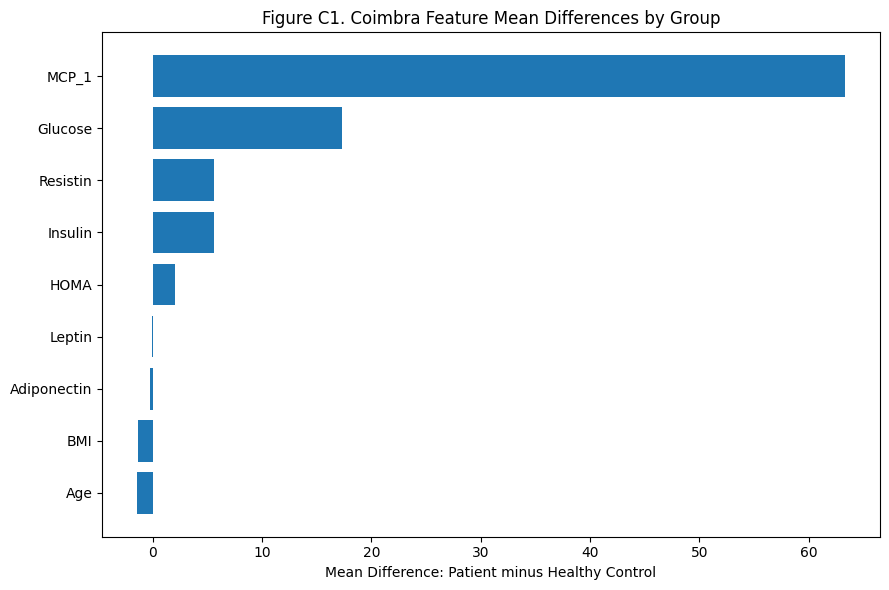

In [26]:
# Figure C1: Coimbra feature mean differences
plot_df = coimbra_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure C1. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()


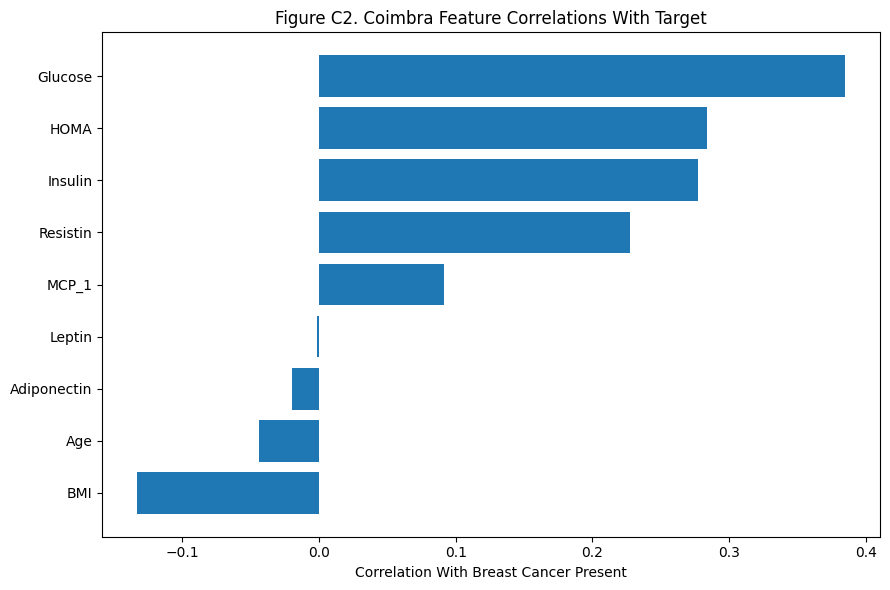

,feature,correlation_with_breast_cancer_present
0,BMI,-0.132586
1,Age,-0.043555
2,Adiponectin,-0.019490
3,Leptin,-0.001078
4,MCP_1,0.091381
5,Resistin,0.227310
6,Insulin,0.276804
7,HOMA,0.284012
8,Glucose,0.384315


In [27]:
# Figure C2: Coimbra correlations with breast cancer presence
coimbra_corr_with_target = coimbra_df[coimbra_features + [coimbra_target]].corr()[coimbra_target].drop(coimbra_target)
coimbra_corr_sorted = coimbra_corr_with_target.sort_values()

plt.figure(figsize=(9, 6))
plt.barh(coimbra_corr_sorted.index, coimbra_corr_sorted.values)
plt.xlabel("Correlation With Breast Cancer Present")
plt.title("Figure C2. Coimbra Feature Correlations With Target")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": coimbra_corr_sorted.index,
    "correlation_with_breast_cancer_present": coimbra_corr_sorted.values
})


#### Coimbra EDA note

The Coimbra predictors are not tumor measurements. They are indirect clinical and blood-based markers. Because of that, I expect the Coimbra dataset to be harder to predict than the Wisconsin dataset.

This is actually useful for the capstone because it lets me compare a strong image-based tumor dataset with a smaller clinical biomarker dataset.

### 2.4 Train-test split

I use a stratified train-test split again so the training and test sets have similar proportions of patients and healthy controls.

Because the Coimbra dataset is small, I will also pay close attention to cross-validation.

In [28]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_coimbra,
    y_coimbra,
    test_size=0.20,
    random_state=42,
    stratify=y_coimbra
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)

Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64

Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


### 2.5 Baseline: ordinary linear regression

I start with ordinary linear regression as a baseline, just like I did for Wisconsin. Since the outcome is binary, I am still treating this as a linear probability model for Week 2 practice.

In [29]:
# Model-evaluation helper. Defined in Part 1; redefined here only if missing,
# so Part 2 can also be run on its own.
try:
    evaluate_model
except NameError:
    def evaluate_model(name, model, X_train, X_test, y_train, y_test):
        model.fit(X_train, y_train)

        train_pred = np.clip(model.predict(X_train), 0, 1)
        test_pred = np.clip(model.predict(X_test), 0, 1)

        test_class = (test_pred >= 0.50).astype(int)

        results = {
            "model": name,
            "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
            "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
            "train_MAE": mean_absolute_error(y_train, train_pred),
            "test_MAE": mean_absolute_error(y_test, test_pred),
            "train_R2": r2_score(y_train, train_pred),
            "test_R2": r2_score(y_test, test_pred),
            "accuracy_at_0.5": accuracy_score(y_test, test_class),
            "recall_malignant_at_0.5": recall_score(y_test, test_class, pos_label=1),
            "precision_malignant_at_0.5": precision_score(y_test, test_class, pos_label=1, zero_division=0)
        }

        return results, train_pred, test_pred

coimbra_baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

coimbra_baseline_results, coimbra_baseline_train_pred, coimbra_baseline_test_pred = evaluate_model(
    "Coimbra Ordinary Linear Regression",
    coimbra_baseline_model,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_baseline_results])


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra Ordinary Linear Regression,0.399587,0.46818,0.346577,0.40972,0.353685,0.117099,0.75,0.692308,0.818182


### 2.6 Ridge regression

Ridge regression uses an L2 penalty. It shrinks coefficients but usually keeps all predictors.

This may be useful for Coimbra because some clinical biomarkers may be related to each other. Ridge can make the model more stable without forcing variables out of the model.

In [30]:
cv_c = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

coimbra_ridge_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

coimbra_ridge_param_grid = {
    "model__alpha": np.logspace(-4, 2, 25)
}

coimbra_ridge_grid = GridSearchCV(
    estimator=coimbra_ridge_pipe,
    param_grid=coimbra_ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv_c
)

coimbra_ridge_grid.fit(X_train_c, y_train_c)

print("Best Coimbra Ridge alpha:", coimbra_ridge_grid.best_params_["model__alpha"])
print("Best Coimbra Ridge CV RMSE:", np.sqrt(-coimbra_ridge_grid.best_score_))

coimbra_ridge_results, coimbra_ridge_train_pred, coimbra_ridge_test_pred = evaluate_model(
    "Coimbra Ridge Regression",
    coimbra_ridge_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_ridge_results])


Best Coimbra Ridge alpha: 100.0
Best Coimbra Ridge CV RMSE: 0.4688430202569062


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra Ridge Regression,0.4426,0.458574,0.427914,0.435263,0.207054,0.152955,0.75,0.692308,0.818182


### 2.7 Lasso regression

Lasso regression uses an L1 penalty. Lasso can shrink some coefficients all the way to zero, so it can act like feature selection.

This is helpful because the Coimbra dataset is small. If lasso can keep fewer features while maintaining performance, the model may be easier to explain.

In [31]:
coimbra_lasso_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000, random_state=42))
])

coimbra_lasso_param_grid = {
    "model__alpha": np.logspace(-4, 1, 25)
}

coimbra_lasso_grid = GridSearchCV(
    estimator=coimbra_lasso_pipe,
    param_grid=coimbra_lasso_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv_c
)

coimbra_lasso_grid.fit(X_train_c, y_train_c)

print("Best Coimbra Lasso alpha:", coimbra_lasso_grid.best_params_["model__alpha"])
print("Best Coimbra Lasso CV RMSE:", np.sqrt(-coimbra_lasso_grid.best_score_))

coimbra_lasso_results, coimbra_lasso_train_pred, coimbra_lasso_test_pred = evaluate_model(
    "Coimbra Lasso Regression",
    coimbra_lasso_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_lasso_results])


Best Coimbra Lasso alpha: 0.0825404185268019
Best Coimbra Lasso CV RMSE: 0.4664041828161654


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra Lasso Regression,0.456249,0.484481,0.442219,0.46934,0.157391,0.054549,0.708333,0.769231,0.714286


### 2.8 Elastic net regression

Elastic net combines ridge and lasso. It uses both L1 and L2 penalties.

This is useful when there are related predictors, because lasso alone may remove too many variables, while ridge alone keeps everything. Elastic net gives a middle ground.

In [32]:
coimbra_elastic_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=42))
])

coimbra_elastic_param_grid = {
    "model__alpha": np.logspace(-4, 1, 20),
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

coimbra_elastic_grid = GridSearchCV(
    estimator=coimbra_elastic_pipe,
    param_grid=coimbra_elastic_param_grid,
    scoring="neg_mean_squared_error",
    cv=cv_c
)

coimbra_elastic_grid.fit(X_train_c, y_train_c)

print("Best Coimbra Elastic Net alpha:", coimbra_elastic_grid.best_params_["model__alpha"])
print("Best Coimbra Elastic Net l1_ratio:", coimbra_elastic_grid.best_params_["model__l1_ratio"])
print("Best Coimbra Elastic Net CV RMSE:", np.sqrt(-coimbra_elastic_grid.best_score_))

coimbra_elastic_results, coimbra_elastic_train_pred, coimbra_elastic_test_pred = evaluate_model(
    "Coimbra Elastic Net Regression",
    coimbra_elastic_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_elastic_results])


Best Coimbra Elastic Net alpha: 0.14384498882876628
Best Coimbra Elastic Net l1_ratio: 0.7
Best Coimbra Elastic Net CV RMSE: 0.46617736397740106


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
0,Coimbra Elastic Net Regression,0.461426,0.484522,0.449611,0.470665,0.138163,0.054387,0.708333,0.846154,0.6875


### 2.9 Model comparison

Now I compare ordinary linear regression, ridge, lasso, and elastic net on the Coimbra dataset.

For Week 2, the main thing I am checking is whether regularization improves the model or makes it easier to interpret.

In [33]:
coimbra_results_df = pd.DataFrame([
    coimbra_baseline_results,
    coimbra_ridge_results,
    coimbra_lasso_results,
    coimbra_elastic_results
])

coimbra_results_df.sort_values("test_RMSE")


,model,train_RMSE,test_RMSE,train_MAE,test_MAE,train_R2,test_R2,accuracy_at_0.5,recall_malignant_at_0.5,precision_malignant_at_0.5
1,Coimbra Ridge Regression,0.442600,0.458574,0.427914,0.435263,0.207054,0.152955,0.750000,0.692308,0.818182
0,Coimbra Ordinary Linear Regression,0.399587,0.468180,0.346577,0.409720,0.353685,0.117099,0.750000,0.692308,0.818182
2,Coimbra Lasso Regression,0.456249,0.484481,0.442219,0.469340,0.157391,0.054549,0.708333,0.769231,0.714286
3,Coimbra Elastic Net Regression,0.461426,0.484522,0.449611,0.470665,0.138163,0.054387,0.708333,0.846154,0.687500


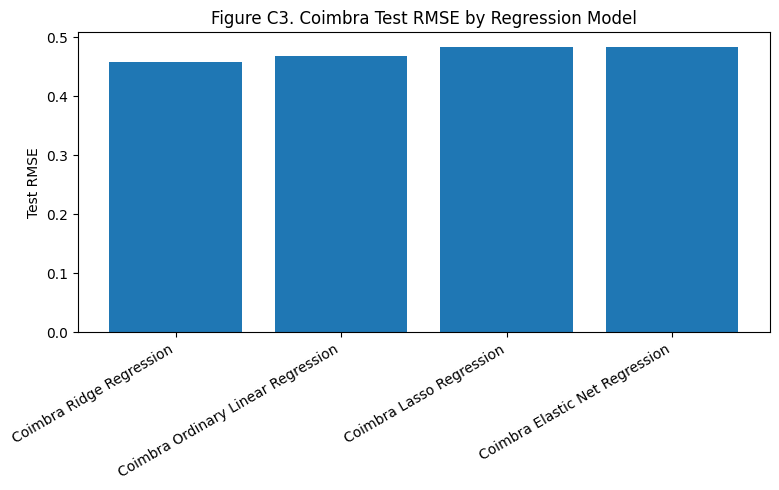

In [34]:
# Figure C3: Coimbra test RMSE comparison
plot_df = coimbra_results_df.sort_values("test_RMSE")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["test_RMSE"])
plt.ylabel("Test RMSE")
plt.title("Figure C3. Coimbra Test RMSE by Regression Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


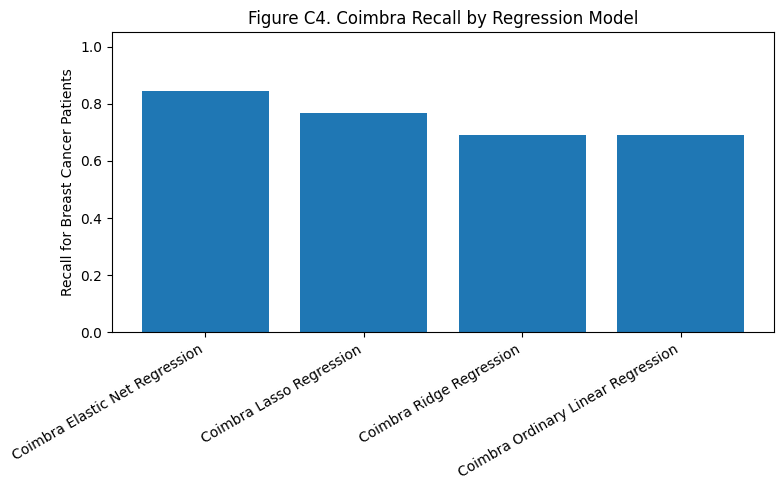

In [35]:
# Figure C4: Coimbra recall comparison
plot_df = coimbra_results_df.sort_values("recall_malignant_at_0.5", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["recall_malignant_at_0.5"])
plt.ylabel("Recall for Breast Cancer Patients")
plt.title("Figure C4. Coimbra Recall by Regression Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 2.10 Cross-validation comparison

The Coimbra dataset is small, so cross-validation is especially important. A single train-test split could give a result that changes a lot depending on which rows fall into the test set.

In [36]:
def cv_rmse_model(model, X_data, y_data, cv):
    scores = cross_val_score(
        model,
        X_data,
        y_data,
        scoring="neg_mean_squared_error",
        cv=cv
    )
    rmse_scores = np.sqrt(-scores)
    return rmse_scores.mean(), rmse_scores.std()

coimbra_models_for_cv = {
    "Coimbra Ordinary Linear Regression": coimbra_baseline_model,
    "Coimbra Ridge Regression": coimbra_ridge_grid.best_estimator_,
    "Coimbra Lasso Regression": coimbra_lasso_grid.best_estimator_,
    "Coimbra Elastic Net Regression": coimbra_elastic_grid.best_estimator_
}

coimbra_cv_summary = []

for name, model in coimbra_models_for_cv.items():
    mean_rmse, std_rmse = cv_rmse_model(model, X_coimbra, y_coimbra, cv_c)
    coimbra_cv_summary.append({
        "model": name,
        "CV_RMSE_mean": mean_rmse,
        "CV_RMSE_std": std_rmse
    })

coimbra_cv_summary_df = pd.DataFrame(coimbra_cv_summary).sort_values("CV_RMSE_mean")
coimbra_cv_summary_df


,model,CV_RMSE_mean,CV_RMSE_std
1,Coimbra Ridge Regression,0.465981,0.016643
0,Coimbra Ordinary Linear Regression,0.471838,0.069570
2,Coimbra Lasso Regression,0.474203,0.016041
3,Coimbra Elastic Net Regression,0.476401,0.013559


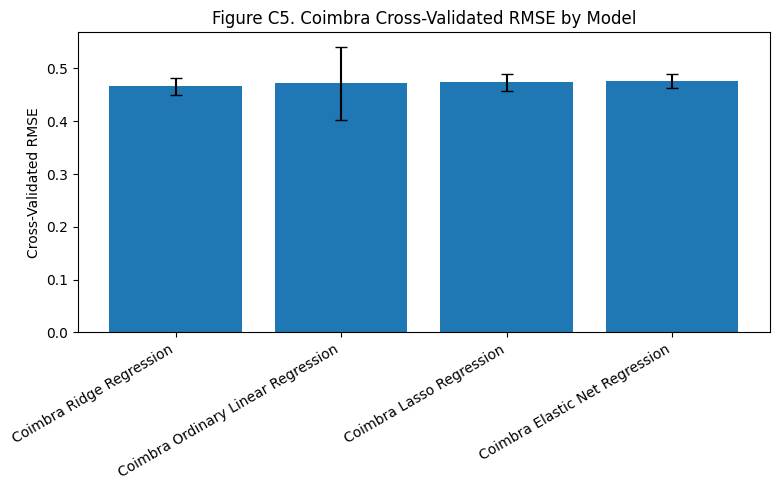

In [37]:
# Figure C5: Coimbra cross-validated RMSE comparison
plot_df = coimbra_cv_summary_df.sort_values("CV_RMSE_mean")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["CV_RMSE_mean"], yerr=plot_df["CV_RMSE_std"], capsize=4)
plt.ylabel("Cross-Validated RMSE")
plt.title("Figure C5. Coimbra Cross-Validated RMSE by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 2.11 Coefficient comparison

This section helps me see how ridge, lasso, and elastic net treat the Coimbra predictors differently.

I expect:

- Ridge will keep all or most predictors
- Lasso may set some coefficients to zero
- Elastic net may land somewhere between ridge and lasso

In [38]:
def get_coimbra_coefficients(fitted_pipeline, feature_names, model_name):
    coefs = fitted_pipeline.named_steps["model"].coef_
    return pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
        "model": model_name
    })

coimbra_coef_dfs = [
    get_coimbra_coefficients(coimbra_baseline_model.fit(X_train_c, y_train_c), coimbra_features, "Coimbra Ordinary Linear Regression"),
    get_coimbra_coefficients(coimbra_ridge_grid.best_estimator_, coimbra_features, "Coimbra Ridge Regression"),
    get_coimbra_coefficients(coimbra_lasso_grid.best_estimator_, coimbra_features, "Coimbra Lasso Regression"),
    get_coimbra_coefficients(coimbra_elastic_grid.best_estimator_, coimbra_features, "Coimbra Elastic Net Regression")
]

coimbra_coef_df = pd.concat(coimbra_coef_dfs, ignore_index=True)

coimbra_coef_df.sort_values(["model", "abs_coefficient"], ascending=[True, False]).groupby("model").head(10)


,feature,coefficient,abs_coefficient,model
29,Glucose,0.107213,0.107213,Coimbra Elastic Net Regression
27,Age,-0.000000,0.000000,Coimbra Elastic Net Regression
28,BMI,-0.000000,0.000000,Coimbra Elastic Net Regression
30,Insulin,0.000000,0.000000,Coimbra Elastic Net Regression
31,HOMA,0.000000,0.000000,Coimbra Elastic Net Regression
32,Leptin,-0.000000,0.000000,Coimbra Elastic Net Regression
33,Adiponectin,-0.000000,0.000000,Coimbra Elastic Net Regression
34,Resistin,0.000000,0.000000,Coimbra Elastic Net Regression
35,MCP_1,-0.000000,0.000000,Coimbra Elastic Net Regression
20,Glucose,0.129991,0.129991,Coimbra Lasso Regression


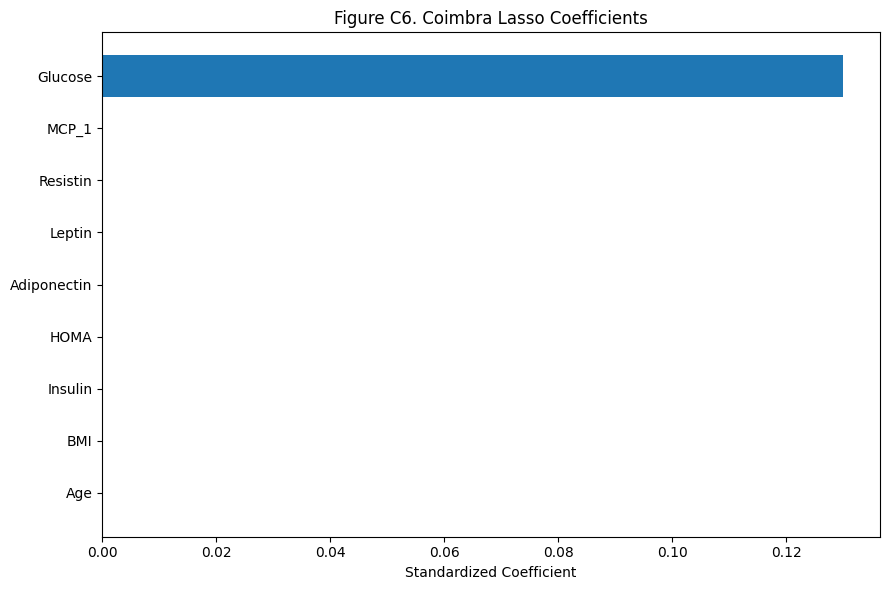

In [39]:
# Figure C6: Coimbra lasso coefficients
coimbra_lasso_coef = coimbra_coef_df[coimbra_coef_df["model"] == "Coimbra Lasso Regression"].copy()
coimbra_lasso_top = coimbra_lasso_coef.sort_values("abs_coefficient", ascending=False).sort_values("coefficient")

plt.figure(figsize=(9, 6))
plt.barh(coimbra_lasso_top["feature"], coimbra_lasso_top["coefficient"])
plt.xlabel("Standardized Coefficient")
plt.title("Figure C6. Coimbra Lasso Coefficients")
plt.tight_layout()
plt.show()


In [40]:
coimbra_coef_count_df = (
    coimbra_coef_df.assign(nonzero=lambda d: d["coefficient"].abs() > 1e-8)
    .groupby("model")["nonzero"]
    .sum()
    .reset_index()
    .rename(columns={"nonzero": "number_of_nonzero_coefficients"})
)

coimbra_coef_count_df


,model,number_of_nonzero_coefficients
0,Coimbra Elastic Net Regression,1
1,Coimbra Lasso Regression,1
2,Coimbra Ordinary Linear Regression,9
3,Coimbra Ridge Regression,9


## Part 3 — Comparison and overall conclusions

### 3.1 Comparison: Wisconsin vs. Coimbra

The Wisconsin dataset and the Coimbra dataset gave me two different ways to think about regularization.

The **Wisconsin dataset** has many tumor image-based features, and several of them are strongly correlated. For example, radius, perimeter, and area all describe tumor size. In that dataset, ridge, lasso, and elastic net are useful because they control coefficient instability caused by many overlapping predictors.

The **Coimbra dataset** is smaller and has fewer predictors. Regularization is still useful, but the reason is slightly different. Since the dataset only has 116 rows, regularization helps reduce overfitting risk. Lasso is also helpful because it can show which clinical or blood-based predictors are strongest after shrinkage.

Overall, Week 2 helped me see that regularization is not only about improving accuracy. It is also about making the model more stable and easier to interpret.

### 3.2 Overall Week 2 conclusions

Across the two datasets, I found that ridge, lasso, and elastic net can be useful in different ways depending on the dataset.

For the Wisconsin dataset, regularization mainly helped with overlapping tumor morphology features. Many of the predictors measure related tumor characteristics, so coefficient shrinkage is important.

For the Coimbra dataset, regularization was important because the dataset is much smaller. With only 116 rows, a regular linear model can be sensitive to the train-test split. Ridge helped shrink coefficients, lasso helped identify a smaller set of predictors, and elastic net gave a balance between the two.

The biggest difference between the datasets is that Wisconsin uses direct tumor measurements, while Coimbra uses indirect clinical and blood-based markers. Because of that, I expect Wisconsin to have stronger predictive performance overall. However, Coimbra is still useful because it shows how routine clinical data may also support breast cancer prediction.

For my capstone, this comparison gives me a stronger story. I am not only asking whether breast cancer can be predicted, but also comparing what kind of data seems more useful for prediction: tumor image-based morphology data or clinical biomarker data.

## References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Linear models: Ridge, lasso, and elastic net*. https://scikit-learn.org/stable/modules/linear_model.html